<a href="https://colab.research.google.com/github/sasya025/aws_lambda_hackathon/blob/main/softwareproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# ---------------------------
# 1. LOAD THE CSV FILE
# ---------------------------
try:
    df = pd.read_csv("creditcard.csv")   # <-- File loads directly here
    print("CSV Loaded Successfully!")
except FileNotFoundError:
    print("ERROR: creditcard.csv not found in your folder!")
    raise

# ---------------------------
# 2. BASIC PREPROCESSING
# ---------------------------

# Drop Time (not required)
if "Time" in df.columns:
    df = df.drop(columns=["Time"])

# Scale Amount
if "Amount" in df.columns:
    scaler = StandardScaler()
    df["Amount_Scaled"] = scaler.fit_transform(df[["Amount"]])
    df = df.drop(columns=["Amount"])

# Separate features and target
X = df.drop(columns=["Class"])
y = df["Class"]

# ---------------------------
# 3. TRAIN–TEST SPLIT
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------------------
# 4. TRAIN MODEL
# ---------------------------
model = LogisticRegression(max_iter=2000, class_weight="balanced")
model.fit(X_train, y_train)

# ---------------------------
# 5. PREDICT & EVALUATE
# ---------------------------
y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\n✔ Fraud Detection Model Completed Successfully!")


CSV Loaded Successfully!

Accuracy: 0.9745619886942172

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962


✔ Fraud Detection Model Completed Successfully!


CSV Loaded Successfully!


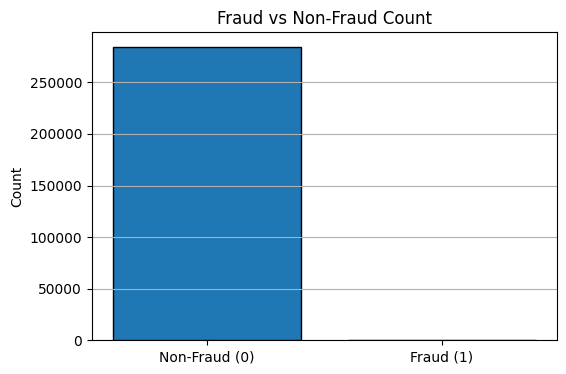

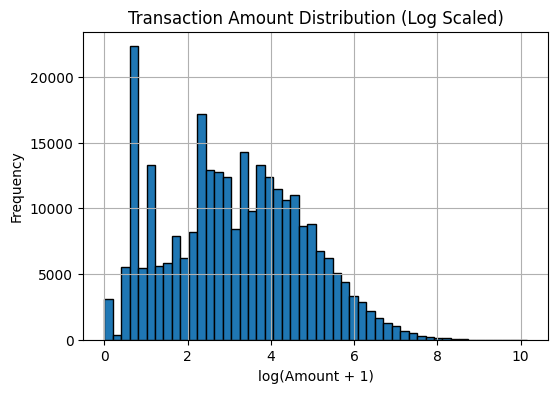


Accuracy: 0.9745619886942172

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



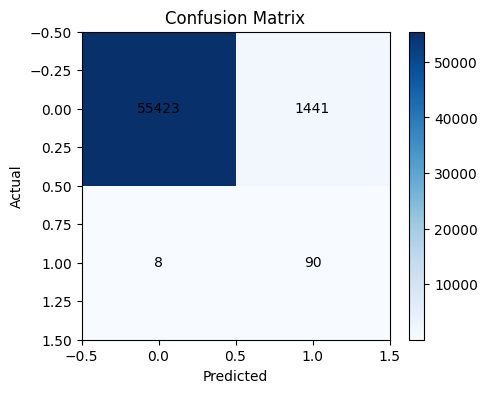

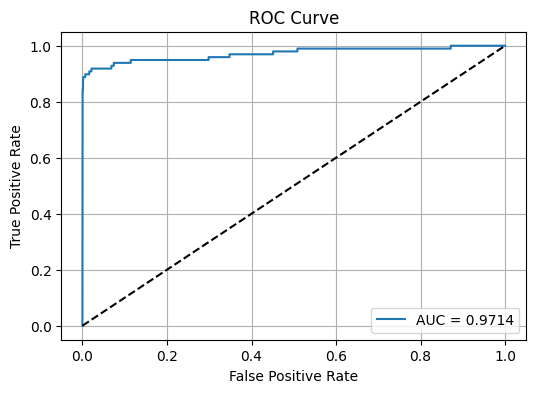

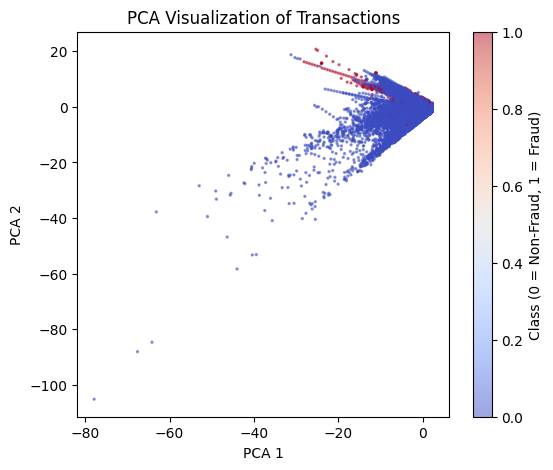


✔ All Visualizations Completed Successfully!


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, roc_auc_score
from sklearn.decomposition import PCA
import numpy as np

# -------------------------------------
# 1. LOAD THE CSV FILE
# -------------------------------------
try:
    df = pd.read_csv("creditcard.csv")
    print("CSV Loaded Successfully!")
except FileNotFoundError:
    print("ERROR: creditcard.csv not found!")
    raise


# -------------------------------------
# 2. VISUALIZATION 1:
#    Fraud vs Non-Fraud Count
# -------------------------------------
counts = df["Class"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(["Non-Fraud (0)", "Fraud (1)"], counts, edgecolor="black")
plt.title("Fraud vs Non-Fraud Count")
plt.ylabel("Count")
plt.grid(axis="y")
plt.show()


# -------------------------------------
# 3. VISUALIZATION 2:
#    Amount Distribution (Log scaled)
# -------------------------------------
if "Amount" in df.columns:
    plt.figure(figsize=(6,4))
    plt.hist(np.log1p(df["Amount"]), bins=50, edgecolor="black")
    plt.title("Transaction Amount Distribution (Log Scaled)")
    plt.xlabel("log(Amount + 1)")
    plt.ylabel("Frequency")
    plt.grid()
    plt.show()


# -------------------------------------
# 4. PREPROCESSING
# -------------------------------------

if "Time" in df.columns:
    df = df.drop(columns=["Time"])

if "Amount" in df.columns:
    scaler = StandardScaler()
    df["Amount_Scaled"] = scaler.fit_transform(df[["Amount"]])
    df = df.drop(columns=["Amount"])

X = df.drop(columns=["Class"])
y = df["Class"]


# -------------------------------------
# 5. TRAIN-TEST SPLIT
# -------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# -------------------------------------
# 6. MODEL TRAINING
# -------------------------------------
model = LogisticRegression(max_iter=2000, class_weight="balanced")
model.fit(X_train, y_train)


# -------------------------------------
# 7. PREDICTION
# -------------------------------------
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


# -------------------------------------
# 8. VISUALIZATION 3:
#    Confusion Matrix
# -------------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# -------------------------------------
# 9. VISUALIZATION 4:
#    ROC Curve
# -------------------------------------
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()


# -------------------------------------
# 10. VISUALIZATION 5:
#     PCA 2D Scatter (Fraud vs Non-Fraud)
# -------------------------------------
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X)

plt.figure(figsize=(6,5))
plt.scatter(
    pca_data[:, 0], pca_data[:, 1],
    c=y, cmap="coolwarm", s=2, alpha=0.5
)
plt.title("PCA Visualization of Transactions")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(label="Class (0 = Non-Fraud, 1 = Fraud)")
plt.show()

print("\n✔ All Visualizations Completed Successfully!")
